In [1]:
import numpy as np
import os
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 16,
    'text.usetex': True,
    'axes.titlesize': 'large',  # Title size
    'axes.titleweight': 'bold',  
    'axes.labelsize': 'LARGE',  
    'axes.labelweight': 'bold',  
    'xtick.labelsize': 'medium',  
    'ytick.labelsize': 'medium',  
    'text.latex.preamble': r'\boldmath',
})

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.minor.width'] = 1
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [2]:
L = 10
temp = np.linspace(2.269, 5, 10)
temp = [temp[0], temp[-7], temp[-3], temp[-1]]

In [3]:
output_dir = "Data2/L_10/Hamming_Distances"
os.makedirs(output_dir, exist_ok=True)


loaded_distances = []
for T in temp:
    filepath = os.path.join(output_dir, f"hamming_dist_T_{T}.npy")
    array = np.load(filepath)
    loaded_distances.append(array)

In [4]:
new_dist = []
for i in range(len(temp)):
    new_dist.append(np.loadtxt(f"Data2/L_10/Hamming_Distances/new_distances_T_{temp[i]}.txt"))

In [5]:
Rc_values = []
for i in range(len(new_dist)):
    Rc_values.append(np.mean(new_dist[i]))

Rc_values = np.array(Rc_values)
Rc_values

array([17.45866667, 45.8018    , 55.6248    , 57.5304    ])

In [6]:
def modifiy(index, loaded_distances):
    dist_load = loaded_distances[index]
    modified_load = [np.insert(arr, i, 0) for i, arr in enumerate(dist_load)]
    modified_load = np.array(modified_load)

    return modified_load

def bond_forming(modified_load, Rc):
    bond_indexa = []
    for i in range(len(modified_load)):
        bonds = np.where((modified_load[i] < Rc) & (np.arange(len(modified_load[i])) != i))[0]
        bond_indexa.append(bonds.tolist())
    return bond_indexa

def distribution(bond_indexa):
    degrees = [len(neighbors) for neighbors in bond_indexa]
    degrees = np.array(degrees)

    maxi_deg = np.max(degrees)
    W = []
    for i in range(maxi_deg + 1):
        W.append([np.sum(degrees == i), i])

    P = np.array(W)[:, 0]
    P = np.array(P)
    degrees_number = np.array(W)[:, 1]
    total_nodes = len(degrees)
    P_distribution = P/total_nodes

    return degrees_number, P, P_distribution

from collections import Counter

def degree_distribution(bond_indexa):
    degrees = [len(neighbors) for neighbors in bond_indexa]
    degrees = np.array(degrees)
    
    degree_count = Counter(degrees)
    total_nodes = len(bond_indexa)
    degree_distribut = {k: v / total_nodes for k, v in degree_count.items()}

    return degree_distribut

In [7]:
#index = -1
#dist_load10 = loaded_distances[index]
#modified_load10 = [np.insert(arr, i, 0) for i, arr in enumerate(dist_load10)]
#modified_load10 = np.array(modified_load10)

#R_10 = Rc_values[index]

#bond_index = []
#for i in range(len(modified_load10)):
#    bond = []
#    for j in range(len(modified_load10[i])):
#        if i != j:
#            if R_10 > modified_load10[i][j]:
#                bond.append(j)
#    bond_index.append(bond)

#bond_indexa = []
#for i in range(len(modified_load10)):
#    bonds = np.where((modified_load10[i] < R_10) & (np.arange(len(modified_load10[i])) != i))[0]
#    bond_indexa.append(bonds.tolist())

#for i, neighbors in enumerate(bond_indexa):
#    for neighbor in neighbors:
#        if i not in bond_indexa[neighbor]:
#            print("concern")

In [8]:
modi_load_temp_5 = modifiy(3, loaded_distances)
bond_index_temp_5 = bond_forming(modi_load_temp_5, Rc_values[3])
degrees_temp5, P_temp5, P_distribution_temp5 = distribution(bond_index_temp_5)

In [9]:
degree_distribution(bond_index_temp_5)

{0: 0.6068,
 1: 0.2739,
 2: 0.0865,
 3: 0.0236,
 4: 0.0064,
 5: 0.002,
 6: 0.0005,
 7: 0.0003}

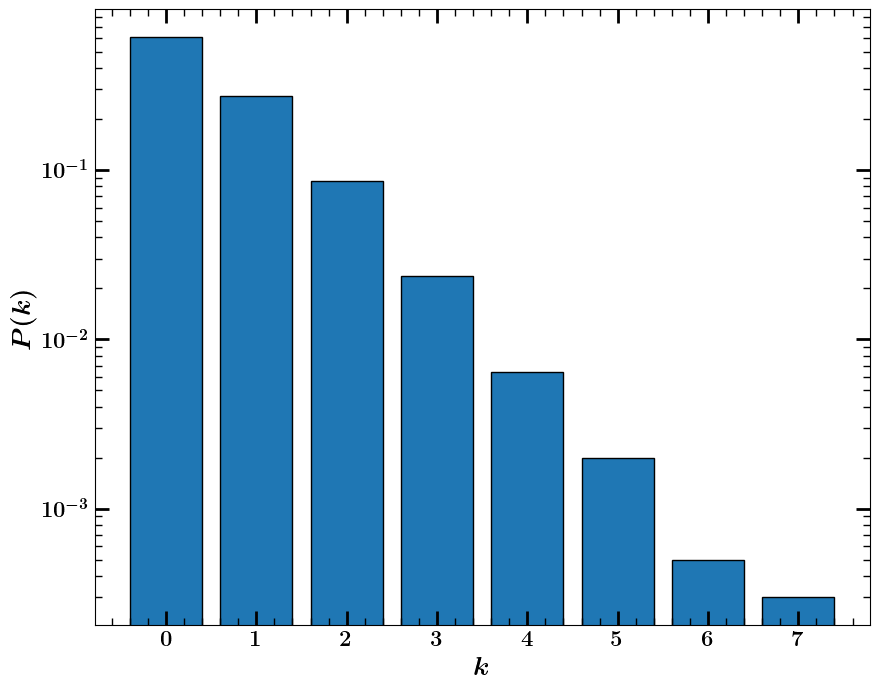

In [10]:
plt.figure(figsize=(10, 8))
plt.bar(degrees_temp5, P_distribution_temp5, edgecolor='black')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.yscale("log")
plt.savefig("Data2/L_10/degree_distribution_10000_samples.pdf", dpi=600)
plt.show()

In [ ]:
graph = nx.Graph()

for node, neighbors in enumerate(bond_index_temp_5):
    for neighbor in neighbors:
        graph.add_edge(node, neighbor)

plt.figure(figsize=(5, 5))

pos = nx.spring_layout(graph, seed=42)
nx.draw(graph, pos, node_size=5, edge_color='black', node_color='blue', with_labels=False)
plt.savefig("Data2/L_10/Graph_10_all_samples.pdf", dpi = 600)
plt.show()

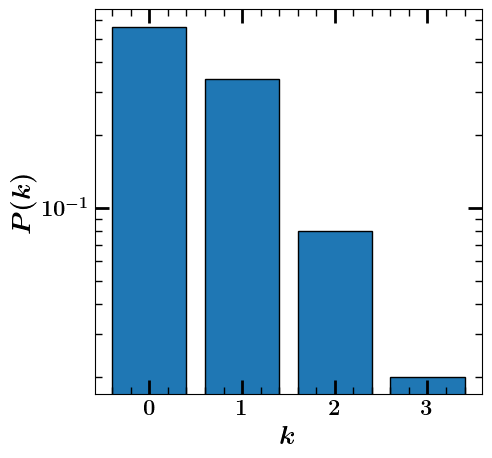

In [46]:
block_size = 100
row_start, col_start = 0, 0
block = modi_load_temp_5[row_start:row_start + block_size, col_start:col_start + block_size]

matrix = block
temp_matrix = np.where(matrix == 0, np.inf, matrix)
min_values = np.min(temp_matrix, axis=1)
min_values[min_values == np.inf] = 0
mean_Rc = np.mean(min_values)

bond_indexa_short = []
for i in range(len(block)):
    bonds = np.where((block[i] < mean_Rc) & (np.arange(len(block[i])) != i))[0]
    bond_indexa_short.append(bonds.tolist())

graph_short = nx.Graph()

for node, neighbors in enumerate(bond_indexa_short):
    for neighbor in neighbors:
        graph_short.add_edge(node, neighbor)

degrees_temp_5n, P_temp_5n, P_distribution_temp_5n = distribution(bond_indexa_short)

plt.figure(figsize=(5, 5))
plt.bar(degrees_temp_5n, P_distribution_temp_5n, edgecolor='black')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.yscale("log")
plt.savefig(f"Data2/L_10/degree_distribution_T_5_{block_size}_samples.pdf")
plt.show()

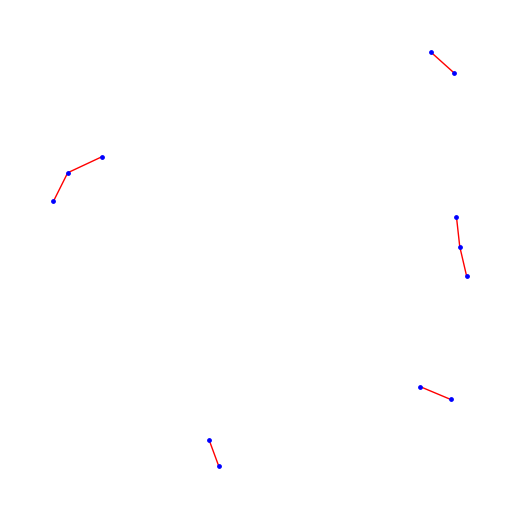

In [33]:
plt.figure(figsize=(5, 5))
pos = nx.spring_layout(graph_short, seed=42)
nx.draw(graph_short, pos, node_size=6, edge_color='red', node_color='blue', with_labels=False)
plt.savefig(f"Data2/L_10/Graph_10_temp_5_{block_size}_samples.pdf", dpi = 600)
plt.show()

# At critical temperature

In [11]:
modi_load_temp_tc = modifiy(0, loaded_distances)
bond_index_temp_tc = bond_forming(modi_load_temp_tc, Rc_values[0])
degrees_temptc, P_temptc, P_distribution_temptc = distribution(bond_index_temp_tc)

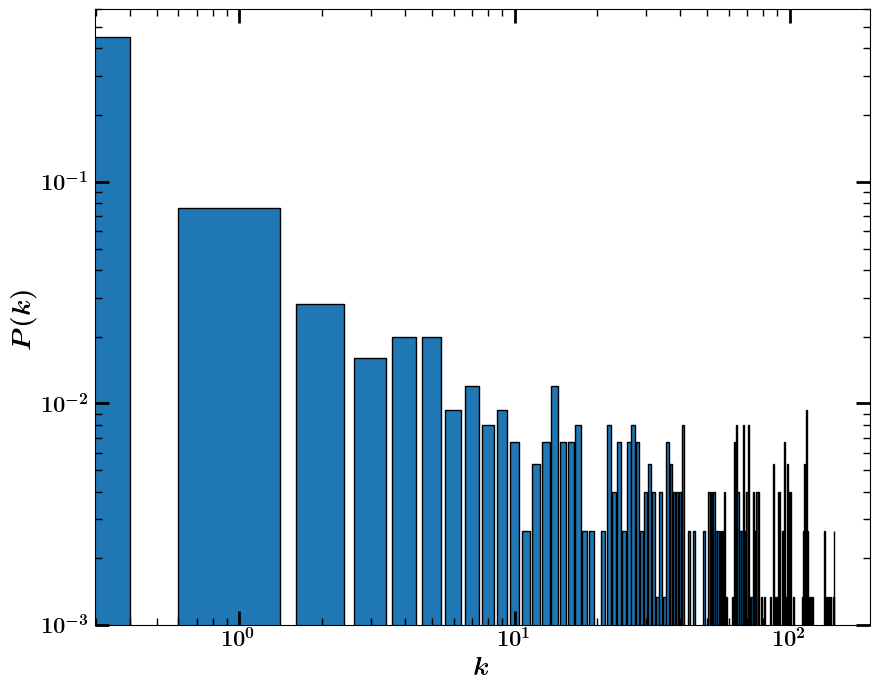

In [12]:
plt.figure(figsize=(10, 8))
plt.bar(degrees_temptc, P_distribution_temptc, edgecolor='black')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.yscale("log")
plt.xscale("log")
plt.savefig("Data2/L_10/degree_distribution_tc_samples.pdf", dpi=600)
plt.show()

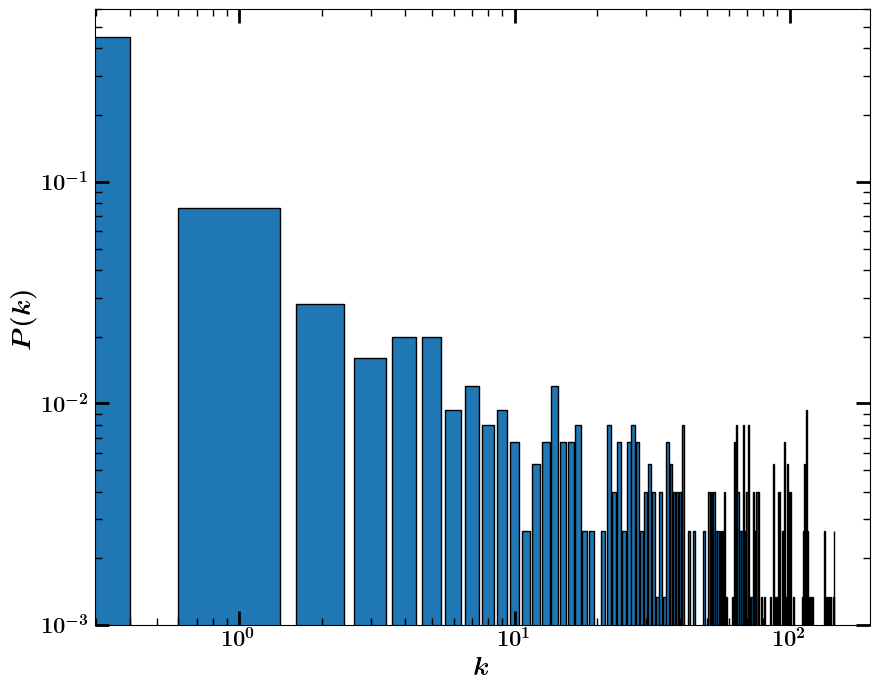

In [52]:
plt.figure(figsize=(10, 8))
plt.bar(degrees_temptc, P_distribution_temptc, edgecolor='black')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.xscale("log")
plt.yscale("log")
plt.savefig("Data2/L_10/degree_distribution_tc_samples_xlim.pdf", dpi=600)
plt.show()

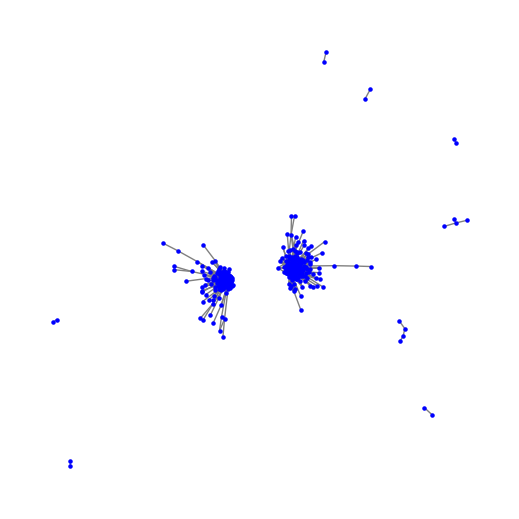

In [27]:
graph = nx.Graph()

for node, neighbors in enumerate(bond_index_temp_tc):
    for neighbor in neighbors:
        graph.add_edge(node, neighbor)

plt.figure(figsize=(5, 5))

pos = nx.spring_layout(graph, seed=42)
nx.draw(graph, pos, node_size=5, edge_color='gray', node_color='blue', with_labels=False)
plt.savefig("Data2/L_10/Graph_10_temp_tc_1000_samples.pdf", dpi = 600)
plt.show()

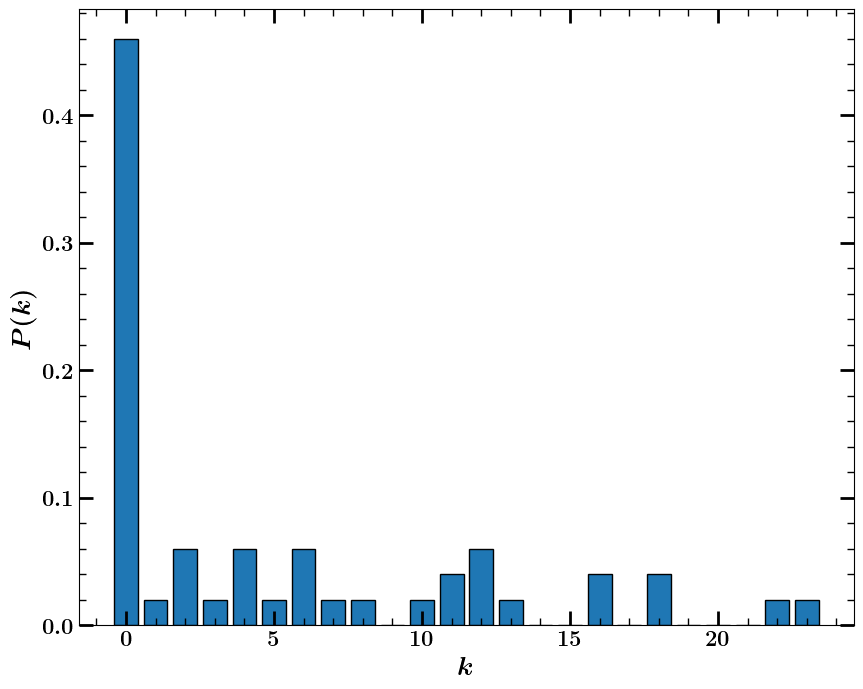

In [39]:
block_size = 50
row_start, col_start = 0, 0
block = modi_load_temp_tc[row_start:row_start + block_size, col_start:col_start + block_size]

matrix = block
temp_matrix = np.where(matrix == 0, np.inf, matrix)
min_values = np.min(temp_matrix, axis=1)
min_values[min_values == np.inf] = 0
mean_Rc = np.mean(min_values)

bond_indexa_short = []
for i in range(len(block)):
    bonds = np.where((block[i] < mean_Rc) & (np.arange(len(block[i])) != i))[0]
    bond_indexa_short.append(bonds.tolist())

graph_short = nx.Graph()

for node, neighbors in enumerate(bond_indexa_short):
    for neighbor in neighbors:
        graph_short.add_edge(node, neighbor)

degrees_temptc, P_temptc, P_distribution_temptc = distribution(bond_indexa_short)

plt.figure(figsize=(10, 8))
plt.bar(degrees_temptc, P_distribution_temptc, edgecolor='black')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.savefig(f"Data2/L_10/degree_distribution_tc_{block_size}_samples.pdf")
plt.show()

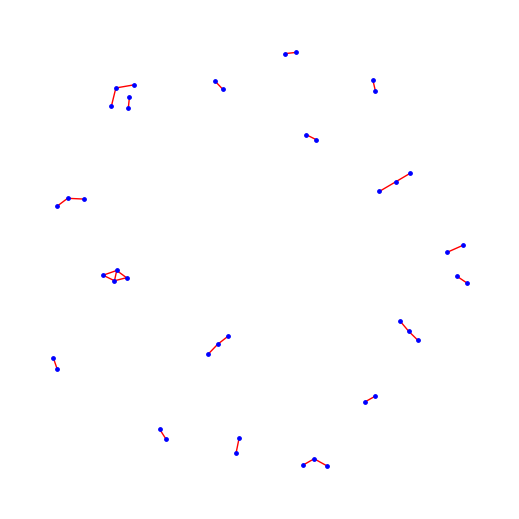

In [53]:
plt.figure(figsize=(5, 5))
pos = nx.spring_layout(graph_short, seed=42)
nx.draw(graph_short, pos, node_size=6, edge_color='red', node_color='blue', with_labels=False)
plt.savefig(f"Data2/L_10/Graph_10_temp_tc_{block_size}_samples.pdf", dpi = 600)
plt.show()

# At T = 4

In [13]:
modi_load_temp_4 = modifiy(-2, loaded_distances)
bond_index_temp_4 = bond_forming(modi_load_temp_4, Rc_values[-2])
degrees_temp_4, P_temp_4, P_distribution_temp_4 = distribution(bond_index_temp_4)

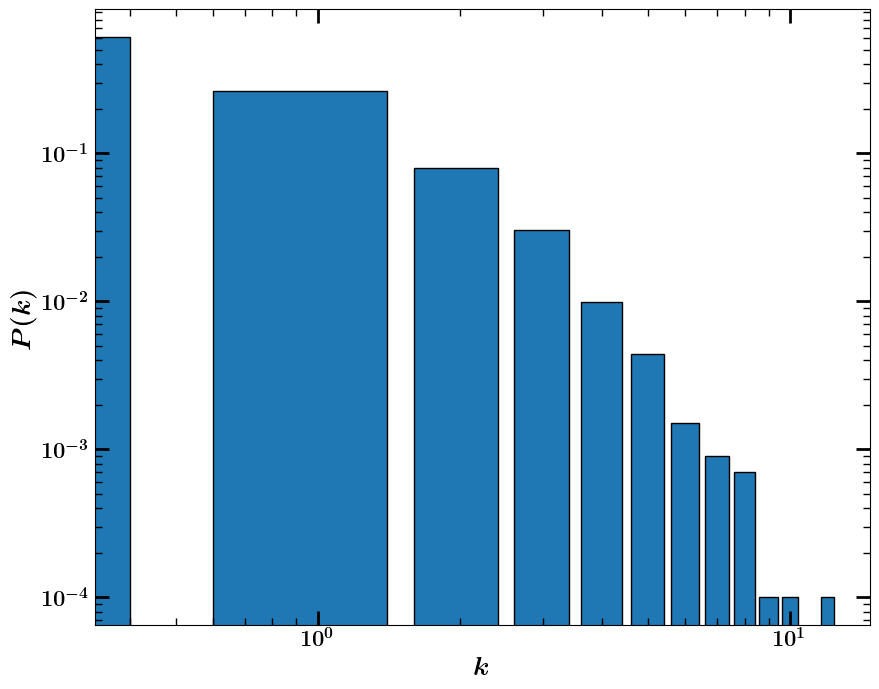

In [14]:
plt.figure(figsize=(10, 8))
plt.bar(degrees_temp_4, P_distribution_temp_4, edgecolor='black')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.xscale("log")
plt.yscale("log")
plt.savefig("Data2/L_10/degree_distribution_temp_4_samples.pdf", dpi=600)
plt.show()

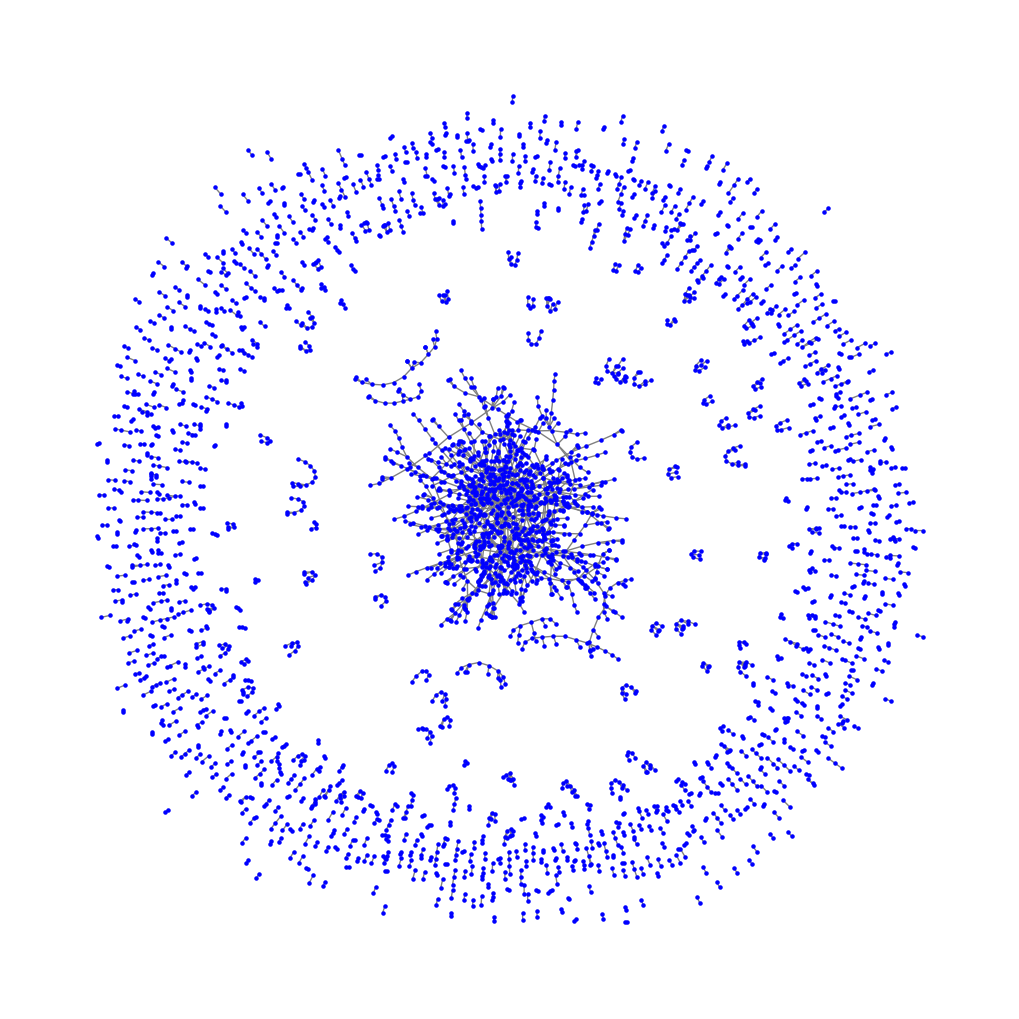

In [ ]:
graph = nx.Graph()

for node, neighbors in enumerate(bond_index_temp_4):
    for neighbor in neighbors:
        graph.add_edge(node, neighbor)

plt.figure(figsize=(5, 5))

pos = nx.spring_layout(graph, seed=42)
nx.draw(graph, pos, node_size=5, edge_color='red', node_color='blue', with_labels=False)
plt.savefig("Data2/L_10/Graph_10_temp_4_1000_samples.pdf", dpi = 600)
plt.show()

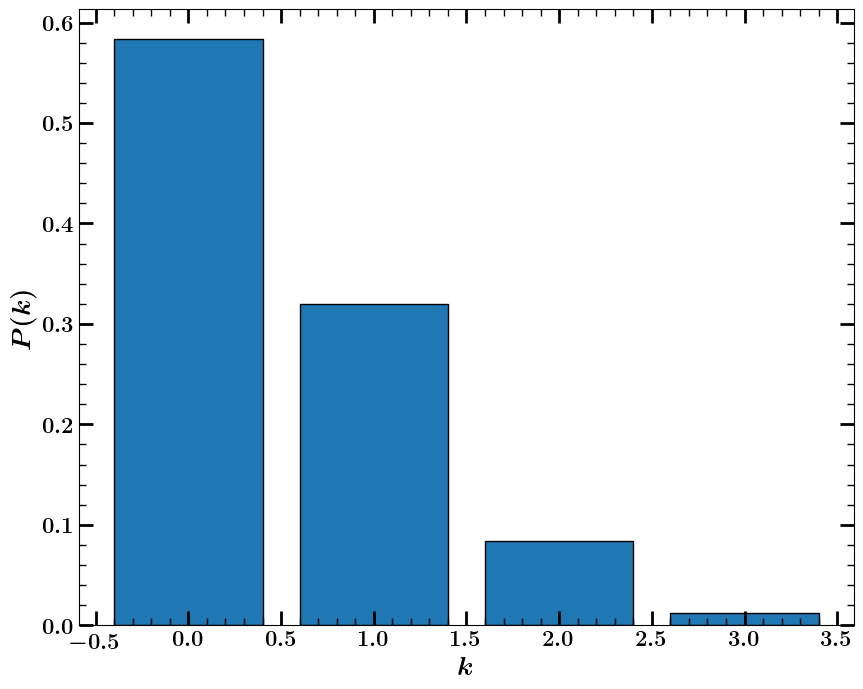

In [60]:
block_size = 500
row_start, col_start = 0, 0
block = modi_load_temp_4[row_start:row_start + block_size, col_start:col_start + block_size]

matrix = block
temp_matrix = np.where(matrix == 0, np.inf, matrix)
min_values = np.min(temp_matrix, axis=1)
min_values[min_values == np.inf] = 0
mean_Rc = np.mean(min_values)

bond_indexa_short = []
for i in range(len(block)):
    bonds = np.where((block[i] < mean_Rc) & (np.arange(len(block[i])) != i))[0]
    bond_indexa_short.append(bonds.tolist())

graph_short = nx.Graph()

for node, neighbors in enumerate(bond_indexa_short):
    for neighbor in neighbors:
        graph_short.add_edge(node, neighbor)

degrees_temp_4n, P_temp_4n, P_distribution_temp_4n = distribution(bond_indexa_short)

plt.figure(figsize=(10, 8))
plt.bar(degrees_temp_4n, P_distribution_temp_4n, edgecolor='black')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.savefig(f"Data2/L_10/degree_distribution_T_4_{block_size}_samples.pdf")
plt.show()

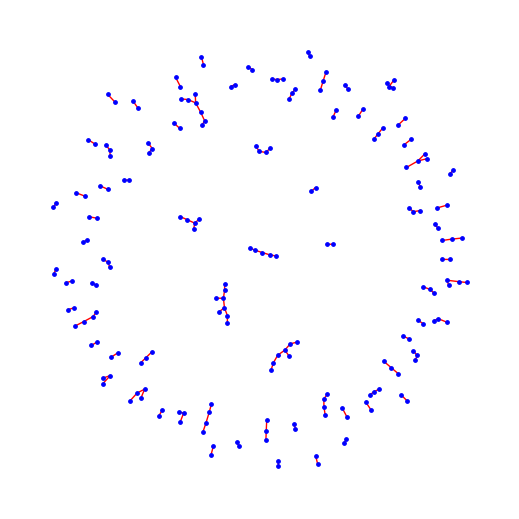

In [61]:
plt.figure(figsize=(5, 5))
pos = nx.spring_layout(graph_short, seed=42)
nx.draw(graph_short, pos, node_size=6, edge_color='red', node_color='blue', with_labels=False)
plt.savefig(f"Data2/L_10/Graph_10_temp_4_{block_size}_samples.pdf", dpi = 600)
plt.show()

# At T = 3.18

In [15]:
modi_load_temp_3 = modifiy(1, loaded_distances)
bond_index_temp_3 = bond_forming(modi_load_temp_3, Rc_values[1])
degrees_temp_3, P_temp_3, P_distribution_temp_3 = distribution(bond_index_temp_3)

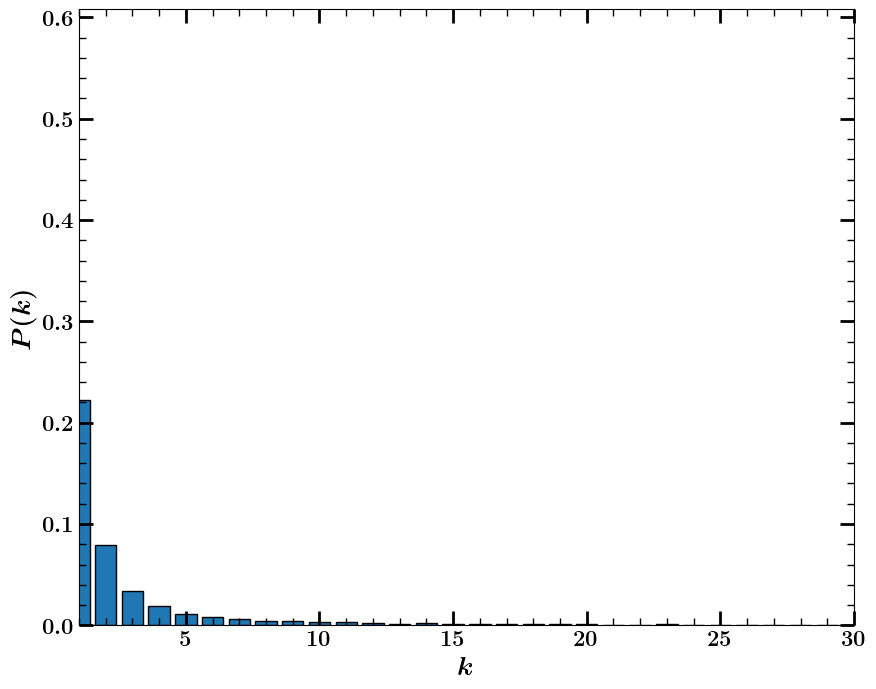

In [16]:
plt.figure(figsize=(10, 8))
plt.bar(degrees_temp_3, P_distribution_temp_3, edgecolor='black')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.savefig("Data2/L_10/degree_distribution_temp_3_samples.pdf", dpi=600)
plt.xlim(1, 30)
plt.show()

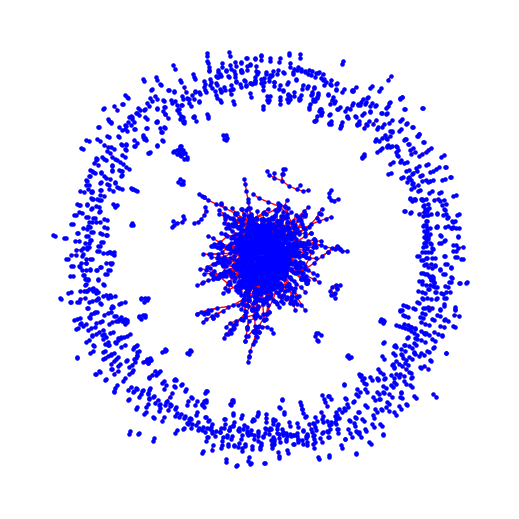

In [64]:
graph = nx.Graph()

for node, neighbors in enumerate(bond_index_temp_3):
    for neighbor in neighbors:
        graph.add_edge(node, neighbor)

plt.figure(figsize=(5, 5))

pos = nx.spring_layout(graph, seed=42)
nx.draw(graph, pos, node_size=5, edge_color='red', node_color='blue', with_labels=False)
plt.savefig("Data2/L_10/Graph_10_temp_3_all_samples.pdf", dpi = 600)
plt.show()

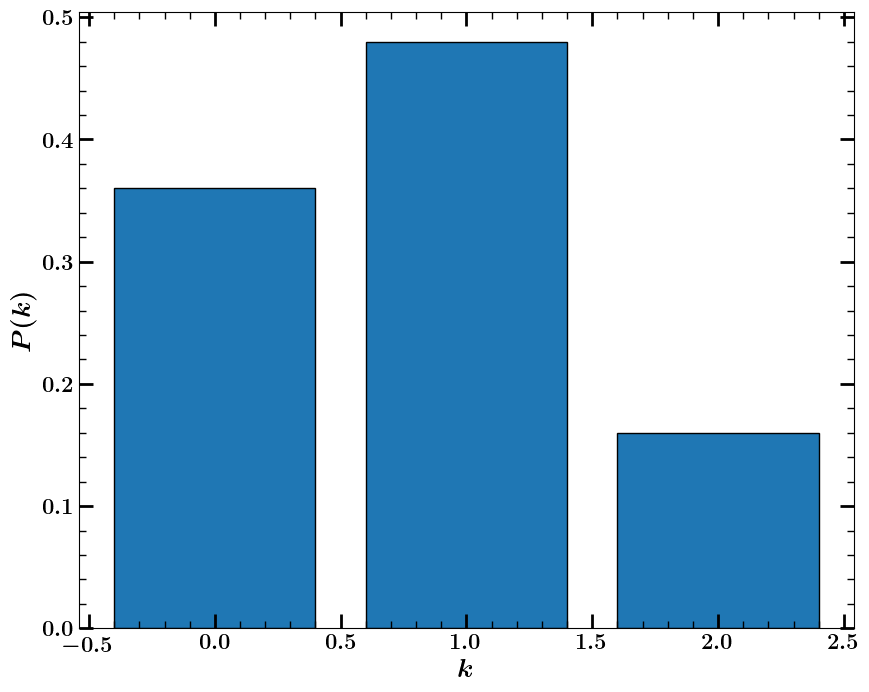

In [38]:
block_size = 25
row_start, col_start = 0, 0
block = modi_load_temp_3[row_start:row_start + block_size, col_start:col_start + block_size]

matrix = block
temp_matrix = np.where(matrix == 0, np.inf, matrix)
min_values = np.min(temp_matrix, axis=1)
min_values[min_values == np.inf] = 0
mean_Rc = np.mean(min_values)

bond_indexa_short = []
for i in range(len(block)):
    bonds = np.where((block[i] < mean_Rc) & (np.arange(len(block[i])) != i))[0]
    bond_indexa_short.append(bonds.tolist())

graph_short = nx.Graph()

for node, neighbors in enumerate(bond_indexa_short):
    for neighbor in neighbors:
        graph_short.add_edge(node, neighbor)

degrees_temp_3n, P_temp_3n, P_distribution_temp_3n = distribution(bond_indexa_short)

plt.figure(figsize=(10, 8))
plt.bar(degrees_temp_3n, P_distribution_temp_3n, edgecolor='black')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.savefig(f"Data2/L_10/degree_distribution_T_3_{block_size}_samples.pdf")
plt.show()

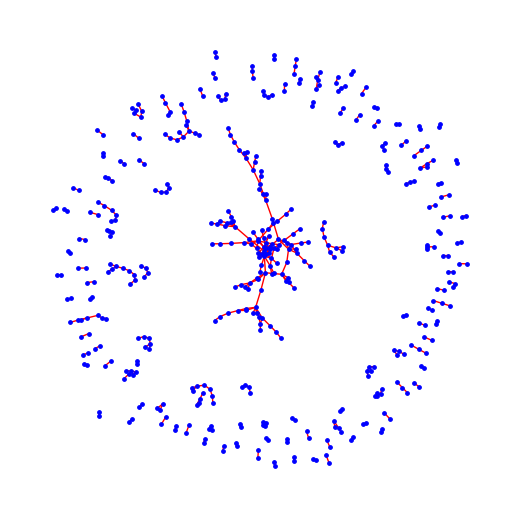

In [72]:
plt.figure(figsize=(5, 5))
pos = nx.spring_layout(graph_short, seed=42)
nx.draw(graph_short, pos, node_size=6, edge_color='red', node_color='blue', with_labels=False)
plt.savefig(f"Data2/L_10/Graph_10_temp_3_{block_size}_samples.pdf", dpi = 600)
plt.show()

# Curves

In [60]:
from scipy.optimize import curve_fit
from scipy.stats import linregress

In [58]:
degrees_temp5, P_distribution_temp5

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 array([6.068e-01, 2.739e-01, 8.650e-02, 2.360e-02, 6.400e-03, 2.000e-03,
        5.000e-04, 3.000e-04]))

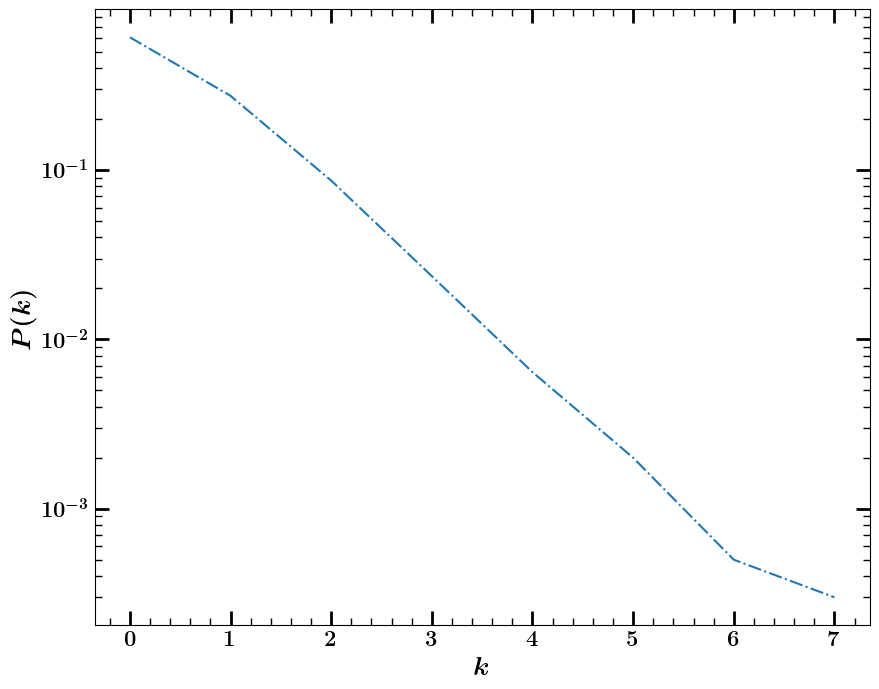

In [37]:
plt.figure(figsize=(10, 8))
plt.plot(degrees_temp5, P_distribution_temp5, "-.")
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.yscale("log")
plt.show()

In [61]:
log_y = np.log(P_distribution_temp5)
slope, intercept, r_value, p_value, std_err = linregress(degrees_temp5, log_y)

b = -slope
b

1.1597701912922225

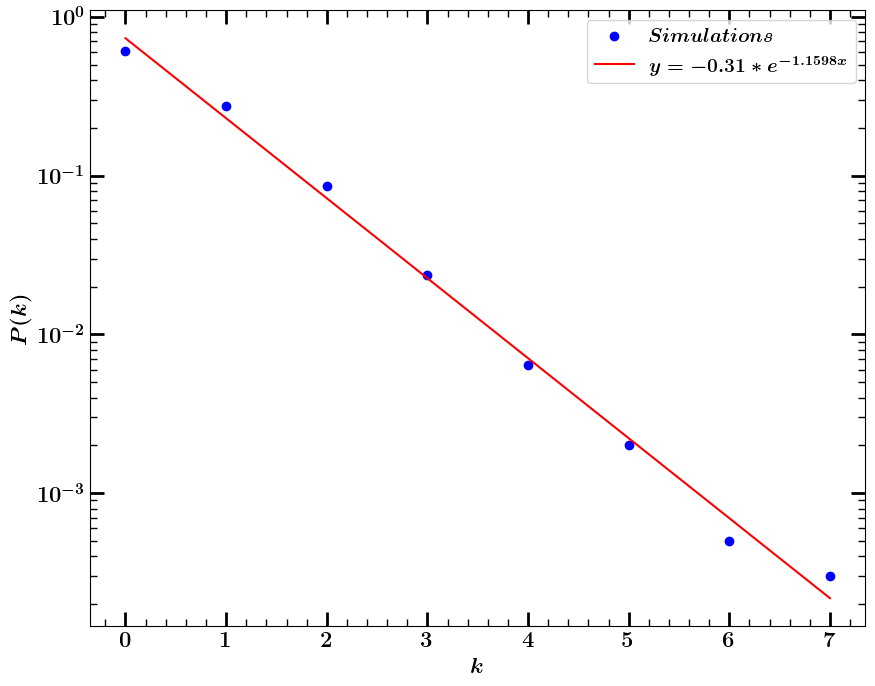

In [79]:
k = degrees_temp5
P_k = P_distribution_temp5
log_P_k = np.log(P_k)

def linear_fit(k, a, b):
    return a * k + b

params, _ = curve_fit(linear_fit, k, log_P_k)
a, b = params

P_k_fit = np.exp(linear_fit(k, a, b))

plt.figure(figsize=(10, 8))
plt.scatter(k, P_k, color='blue', label=r'$Simulations$')
plt.plot(k, P_k_fit, color='red', label=f'$y = {b:.2f}*e^{{{a:.4f}x}}$')
plt.xlabel(r'$k$', fontsize=16)
plt.ylabel(r'$P(k)$', fontsize=16)
plt.yscale('log')
plt.legend(fontsize=14)
plt.show()

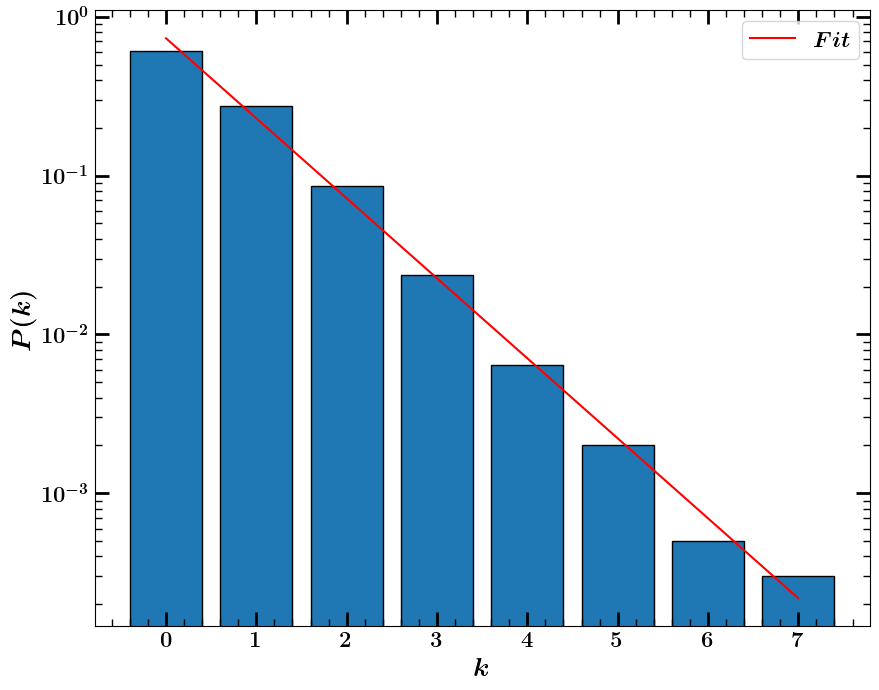

In [40]:
plt.figure(figsize=(10, 8))
plt.bar(degrees_temp5, P_distribution_temp5, edgecolor='black')
plt.plot(k, P_k_fit, color='red', label=r'$Fit$')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.yscale("log")
plt.legend()
plt.show()

# Critical temperature regime

In [82]:
x = np.array(degrees_temptc[0:15])
y = np.array(P_distribution_temptc[0:15])
x, y 

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
 array([0.44933333, 0.076     , 0.028     , 0.016     , 0.02      ,
        0.02      , 0.00933333, 0.012     , 0.008     , 0.00933333,
        0.00666667, 0.00266667, 0.00533333, 0.00666667, 0.012     ]))

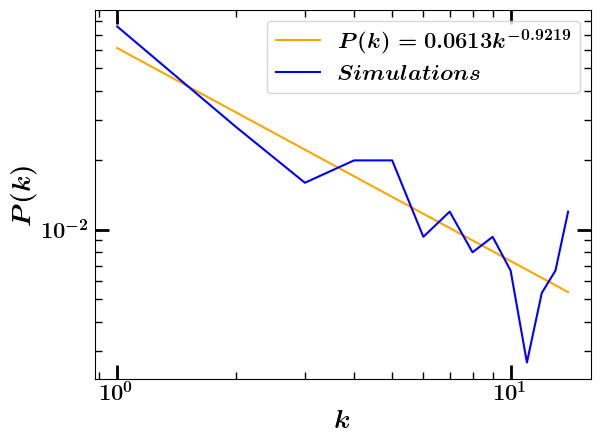

In [150]:
x = np.array(degrees_temptc[1:15])  # k values
y = np.array(P_distribution_temptc[1:15])  # P(k) values

log_x = np.log(x)
log_y = np.log(y)

slope, intercept, r_value, p_value, std_err = linregress(log_x, log_y)

p = -slope
b = np.exp(intercept)
fitted_y = b * x**(-p)

plt.plot(x, fitted_y, label=f"$P(k) = {b:.4f} k^{{-{p:.4f}}}$", color="orange")
plt.plot(x, y, label=r"$Simulations$", color="blue")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.legend()
plt.show()

In [148]:
print(f"Fitted parameters: b = {b:.4f}, p = {p:.4f}")
print(f"Standard deviation of b = {np.exp(std_err):.4f}")
print(f"Standard deviation of p = {std_err:.4f}")

Fitted parameters: b = 0.0613, p = 0.9219
Standard deviation of b = 1.1575
Standard deviation of p = 0.1462


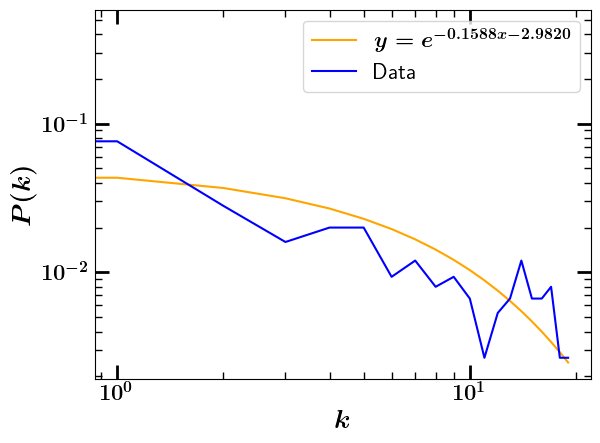

In [151]:
x = np.array(degrees_temptc[0:20])
y = np.array(P_distribution_temptc[0:20])

log_y = np.log(y)
slope, intercept, r_value, p_value, std_err = linregress(x, log_y)
b = -slope
c = intercept
fitted_y = np.exp(-b * x + c)

plt.plot(x, fitted_y, label=f"$y = e^{{-{b:.4f}x {c:.4f}}}$", color="orange")
plt.plot(x, y, label="Data", color="blue")
plt.xscale("log")
plt.yscale("log")
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.legend()
plt.show()

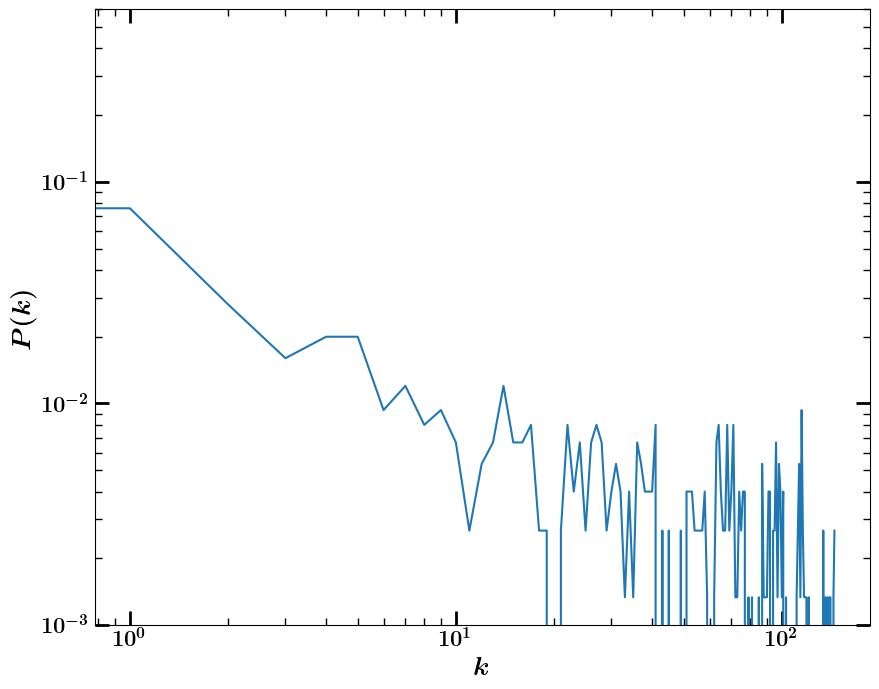

In [44]:
plt.figure(figsize=(10, 8))
plt.plot(degrees_temptc, P_distribution_temptc)
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.yscale("log")
plt.xscale("log")
plt.show()

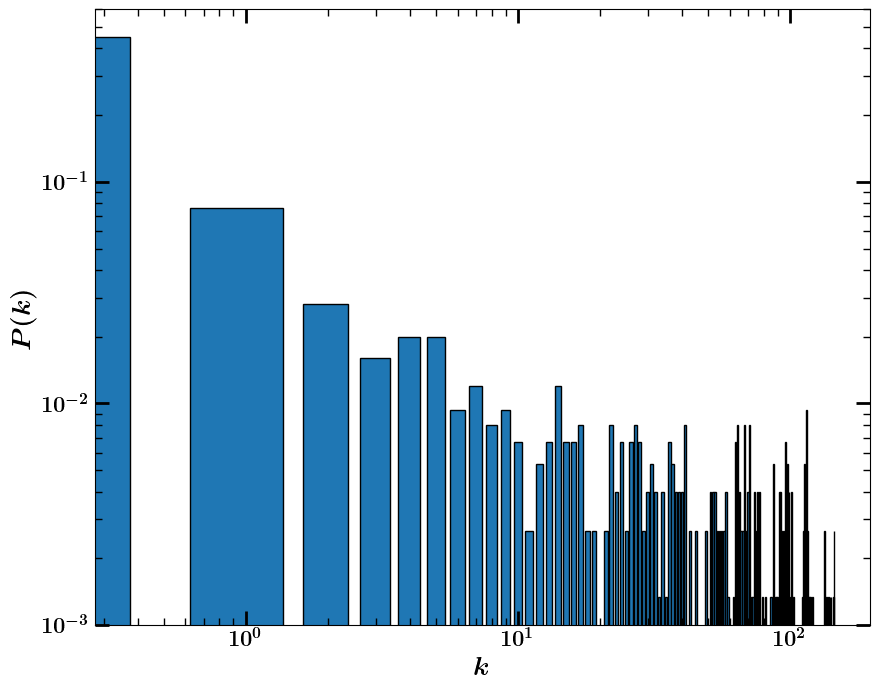

In [172]:
plt.figure(figsize=(10, 8))
plt.bar(degrees_temptc, P_distribution_temptc, edgecolor='black', width = 0.75)
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.yscale("log")
plt.xscale("log")
plt.show()

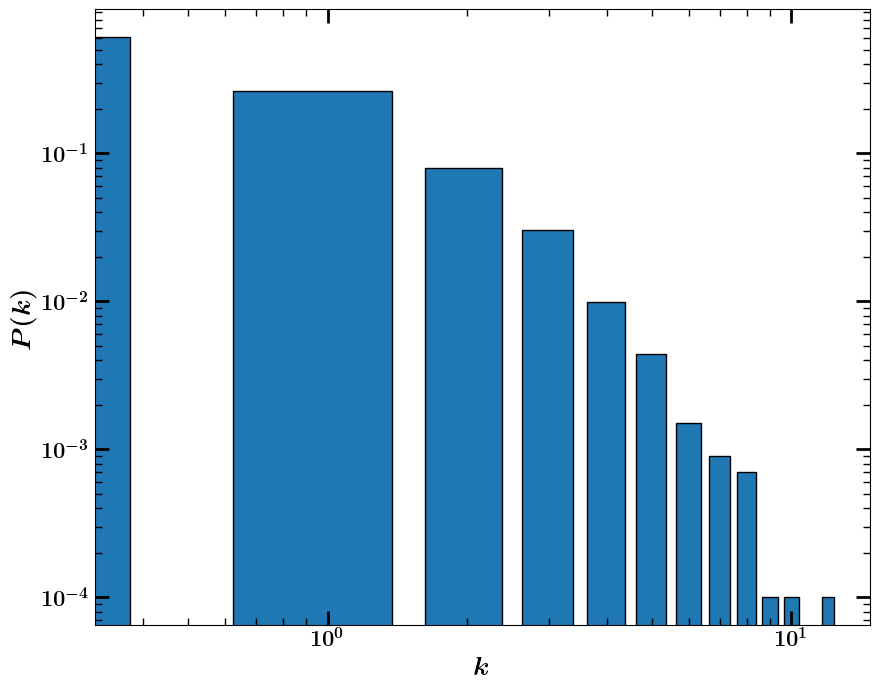

In [157]:
plt.figure(figsize=(10, 8))
plt.bar(degrees_temp_4, P_distribution_temp_4, edgecolor='black', width = 0.75)
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.yscale("log")
plt.xscale("log")
plt.show()

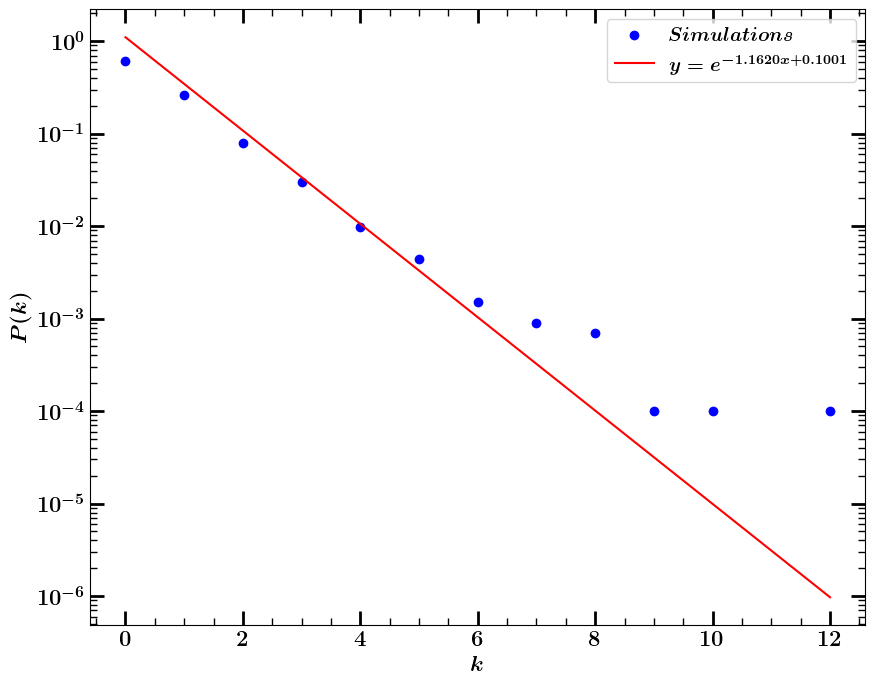

In [104]:
k, P_k = degrees_temp_4, P_distribution_temp_4
epsilon = 1e-10
log_P_k = np.log(P_k + epsilon)

def linear_fit(k, a, b):
    return a * k + b

params, _ = curve_fit(linear_fit, k, log_P_k)
a, b = params
P_k_fit = np.exp(linear_fit(k, a, b))


plt.figure(figsize=(10, 8))
plt.scatter(k, P_k, color='blue', label=r'$Simulations$')
plt.plot(k, P_k_fit, color='red', label=f'$y = e^{{{a:.4f}x + {b:.4f}}}$')
plt.xlabel(r'$k$', fontsize=16)
plt.ylabel(r'$P(k)$', fontsize=16)
plt.yscale('log')
plt.legend(fontsize=14)
plt.show()

In [142]:
cleaned_data, cleaned_degrees = zip(*[(p, d) for p, d in zip(P_distribution_temp_3, degrees_temp_3) if p != 0])
cleaned_data = list(cleaned_data)
cleaned_degrees = list(cleaned_degrees)

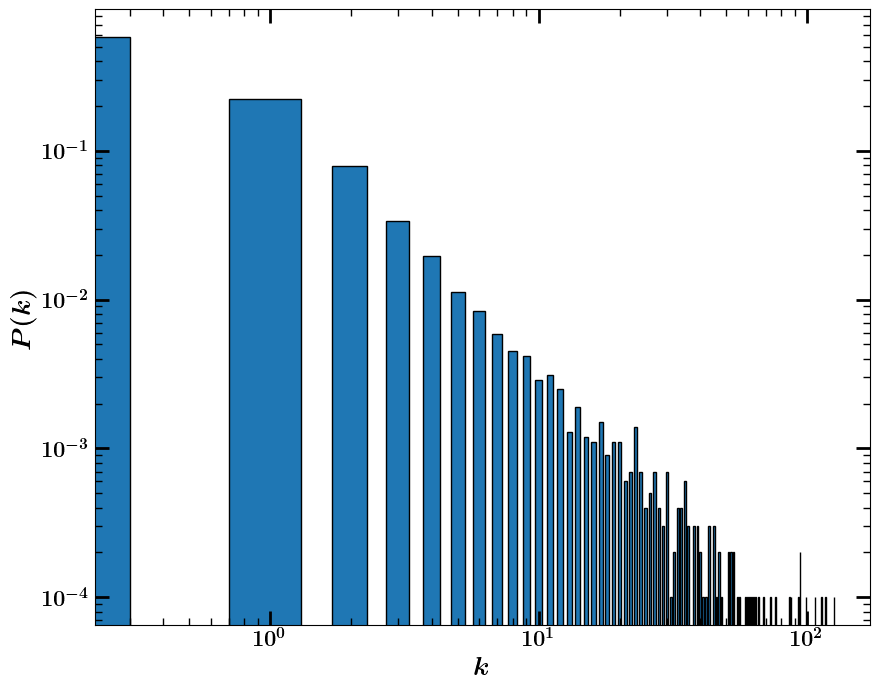

In [162]:
plt.figure(figsize=(10, 8))
plt.bar(cleaned_degrees, cleaned_data, edgecolor='black', width = 0.6)
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.xscale("log")
plt.yscale("log")
plt.show()

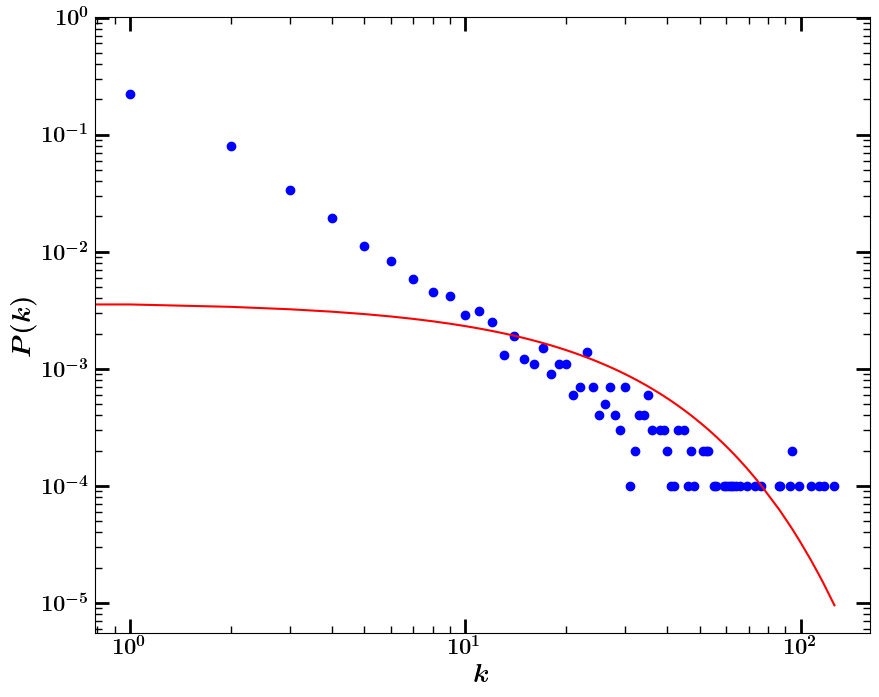

In [138]:
k = np.array(cleaned_degrees)
P_k = np.array(cleaned_data)

log_P_k = np.log(P_k)

def linear_fit(k, a, b):
    return a * k + b

params, _ = curve_fit(linear_fit, k, log_P_k)
a, b = params

P_k_fit = np.exp(linear_fit(k, a, b))

plt.figure(figsize=(10, 8))
plt.scatter(k, P_k, color='blue', label=r'$Simulations$')
plt.plot(k, P_k_fit, color='red', label=f'$y = {b:.2f}*e^{{{a:.4f}x}}$')
plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.xticks()
plt.yticks()
plt.yscale("log")
plt.xscale("log")
plt.show()